# Final Project — GastroVision (bản **CPU-only**)

**Môn:** AIN501 — Deep Learning &nbsp;&nbsp;|&nbsp;&nbsp; **Nhóm:** 2 thành viên

---

## 1. Notebook này là gì

Đây là **phiên bản chuẩn hoá chạy CPU** của `gastrovision_classification.ipynb`.
Mọi phép tính — huấn luyện, đánh giá, đo độ trễ — đều bị **ép chạy hoàn toàn trên CPU**,
kể cả khi máy có GPU NVIDIA. Ba lớp bảo vệ:

1. `CUDA_VISIBLE_DEVICES = ""` được đặt **trước khi import torch** → PyTorch không nhìn thấy GPU nào.
2. `DEVICE = torch.device("cpu")` được ghi cứng, kèm `assert not torch.cuda.is_available()`.
3. Mọi lời gọi `.cuda()` trên Tensor / Module đều bị **chặn và báo lỗi ngay** (guard ở ô đầu tiên).

## 2. Khác gì bản GPU

| Hạng mục | Bản GPU (Colab) | Bản CPU này |
| --- | --- | --- |
| Thiết bị | tự nhận diện T4 / A100 | **luôn CPU**, có guard chống rơi về CUDA |
| Kiểu số | AMP bf16/fp16 + TF32 | **fp32 thuần** (CPU không có AMP đáng dùng) |
| Mô hình mặc định | DenseNet-121 / Swin-T / CoAtNet-0 | **MobileNetV3-Large** (nhẹ, hợp CPU); DenseNet-121 bật bằng cờ |
| Quy mô | toàn bộ dữ liệu, 30 epoch, 3 seed | hồ sơ `cpu-lite` (mặc định) hoặc `cpu-full` |
| Mục đích số đo | số đưa vào báo cáo | **kiểm thử pipeline + minh hoạ**; muốn số thật vẫn phải chạy đủ dữ liệu (`cpu-full`, rất lâu) |

Phần **không đổi** so với bản GPU — để hai notebook so sánh được với nhau:
cùng luật lọc lớp (> 25 ảnh → 22 lớp), cùng chia phân tầng 60:20:20 với `SPLIT_SEED = 42`,
cùng chỉ số (macro-F1 + micro-F1 + F1 từng lớp + ma trận nhầm lẫn + bootstrap CI),
cùng cấu trúc hàm (`evaluate` trả logits, `run_seeds` tự khôi phục từ `.npz`).

> ⚠️ Số đo ở hồ sơ `cpu-lite` **không có giá trị khoa học** (mỗi lớp chỉ vài ảnh test).
> Nó chứng minh thuật toán chạy đúng và trọn vẹn trên CPU — không phải để trích vào báo cáo.

---
## 3. Ép CPU — phải là ô chạy **đầu tiên**

`CUDA_VISIBLE_DEVICES` chỉ được torch đọc **một lần lúc khởi tạo**, nên phải đặt trước khi
`import torch`. Nếu bạn đã lỡ import torch ở ô khác trước đó → `Kernel → Restart` rồi chạy lại từ đây.

In [1]:
# ----------------------- EP TOAN BO PIPELINE CHAY TREN CPU -----------------------
# Buoc 1: an moi GPU NVIDIA TRUOC khi import torch (torch chi doc bien nay luc khoi tao).
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""
os.environ.setdefault("OMP_NUM_THREADS", str(os.cpu_count() or 1))   # MKL/OpenMP dung het nhan

import sys, io, json, math, time, random, hashlib, zipfile, warnings, collections
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision as tv
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 9

# Buoc 2: ghi cung thiet bi + kiem chung CUDA da bien mat that su.
DEVICE = torch.device("cpu")
assert not torch.cuda.is_available(), (
    "CUDA van hien dien! CUDA_VISIBLE_DEVICES phai duoc dat TRUOC khi import torch. "
    "Restart kernel roi chay lai notebook tu o nay.")

# Buoc 3: guard — moi loi goi .cuda() tu day ve sau deu bao loi ngay thay vi lang le doi thiet bi.
def _no_cuda(*a, **k):
    raise RuntimeError("Notebook CPU-only: cam goi .cuda() / .to('cuda').")

torch.Tensor.cuda = _no_cuda
torch.nn.Module.cuda = _no_cuda

# Buoc 4: cho CPU dung het so nhan co san (intra-op); interop chi dat duoc 1 lan nen boc try.
N_THREADS = os.cpu_count() or 1
torch.set_num_threads(N_THREADS)
try:
    torch.set_num_interop_threads(max(1, N_THREADS // 2))
except RuntimeError:
    pass   # da co phep tinh song song chay truoc do -> giu gia tri hien tai

print("torch       :", torch.__version__)
print("torchvision :", tv.__version__)
print("device      :", DEVICE)
print("cuda visible:", torch.cuda.is_available(), "(phai la False)")
print("so luong CPU threads:", torch.get_num_threads())

torch       : 2.13.0+cpu
torchvision : 0.28.0+cpu
device      : cpu
cuda visible: False (phai la False)
so luong CPU threads: 12


---
## 4. Hồ sơ chạy CPU

Hai hồ sơ, chọn bằng `PROFILE`:

| Hồ sơ | Dữ liệu | Epoch | Seed | Thời gian ước tính (MobileNetV3) | Mục đích |
| --- | --- | --- | --- | --- | --- |
| `cpu-lite` (mặc định) | 40/12/12 ảnh mỗi lớp | 5 | [0] | ~10–25 phút | kiểm thử pipeline trọn vẹn trên CPU |
| `cpu-full` | toàn bộ (~8.000 ảnh) | 15 | [0] | **nhiều giờ** | lấy số CPU thật (chỉ khi thật sự cần) |

Không có AMP: trên CPU, autocast bf16 thường **chậm hơn** fp32 với mạng conv và làm số đo khó
so sánh — bản CPU này dùng **fp32 thuần** cho cả huấn luyện lẫn suy luận.

In [2]:
# --------------------------- CAU HINH THUC NGHIEM (CPU) ---------------------------
PROFILE = "cpu-full"          # "cpu-lite" | "cpu-full"

SPLIT_SEED    = 42            # CO DINH cho ca nhom -> chia du lieu giong het ban GPU
IMG_SIZE      = 224
MIN_PER_CLASS = 25            # luat cua bai bao: giu lop co > 25 anh -> 22 lop
KEEP_TOP_K    = 3             # giu top-3 checkpoint theo val (nhu ban GPU)
SMOOTH_WIN    = 3

PROFILES = {
    "cpu-lite": dict(epochs=5,  batch=16, seeds=[0], cap=(40, 12, 12), latency_iters=30),
    "cpu-full": dict(epochs=15, batch=16, seeds=[0], cap=None,         latency_iters=100),
}
CFG = PROFILES[PROFILE]

EPOCHS      = CFG["epochs"]
BATCH_SIZE  = CFG["batch"]
SEEDS       = CFG["seeds"]
NUM_WORKERS = 0 if os.name == "nt" else 2   # Windows + Dataset trong notebook -> loi pickle neu > 0
PIN_MEMORY  = False                          # pin memory chi co y nghia khi copy sang GPU
IS_LITE     = PROFILE == "cpu-lite"

print(f"PROFILE = {PROFILE}  (device={DEVICE})")
print(f"  epochs={EPOCHS}  batch={BATCH_SIZE}  seeds={SEEDS}  workers={NUM_WORKERS}")
print(f"  gioi han anh moi lop (train/val/test) = {CFG['cap']}")
if IS_LITE:
    print("\n" + "!" * 78)
    print("!! CHE DO cpu-lite: con so macro-F1 duoi day KHONG co gia tri khoa hoc.")
    print("!! Muc dich: chung minh thuat toan chay dung va tron ven 100% tren CPU.")
    print("!" * 78)

PROFILE = cpu-full  (device=cpu)
  epochs=15  batch=16  seeds=[0]  workers=0
  gioi han anh moi lop (train/val/test) = None


In [3]:
# --- Tinh lap lai: tren CPU pipeline nay TAT DINH hoan toan (khong co kernel CUDA bat dinh) ---
DATA_GEN = None


def seed_worker(worker_id):
    s = torch.initial_seed() % 2 ** 32
    np.random.seed(s); random.seed(s)


def set_seed(s=SPLIT_SEED):
    global DATA_GEN
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s)
    torch.use_deterministic_algorithms(True, warn_only=True)
    DATA_GEN = torch.Generator(); DATA_GEN.manual_seed(s)


set_seed()
print("set_seed OK — CPU + fp32 + seed co dinh => hai lan chay cung seed ra cung ket qua")

set_seed OK — CPU + fp32 + seed co dinh => hai lan chay cung seed ra cung ket qua


---
## 5. Dữ liệu

Bản CPU đọc từ `deep-learning-final/data/` (giống chế độ máy cá nhân của bản GPU), tự giải nén
zip lồng nếu có. Giữ **nguyên** luật lọc lớp và phép chia của bản GPU để hai notebook đối chiếu được.

In [4]:
IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}


def count_images(root):
    root = Path(root)
    if not root.exists():
        return 0
    return sum(1 for r, _, fs in os.walk(root)
               for f in fs if os.path.splitext(f)[1].lower() in IMG_EXT)


def extract_all_zips(base, max_rounds=6):
    '''Giai nen moi .zip duoi base (kho luu tru goc la ZIP LONG ZIP).'''
    base = Path(base)
    for _ in range(max_rounds):
        if count_images(base) > 1000:
            return
        inner = list(base.rglob("*.zip"))
        if not inner:
            return
        for z in inner:
            print("giai nen zip long:", z.name)
            tmp = z.with_name(z.name + ".processing")
            z.rename(tmp)
            try:
                with zipfile.ZipFile(tmp) as f:
                    f.extractall(z.parent)
            except Exception:
                tmp.rename(z)
                raise
            tmp.unlink()


_cwd = Path.cwd()
REPO = _cwd.parent if _cwd.name == "notebooks" else _cwd
BASE = REPO / "data"
CKPT_DIR = REPO / "checkpoints_cpu"      # tach khoi checkpoints cua ban GPU
OUTPUT_DIR = REPO / "outputs_cpu"
CKPT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
extract_all_zips(BASE)

n_img = count_images(BASE)
assert BASE.exists() and n_img > 1000, (
    f"Chi thay {n_img} anh duoi {BASE}. Giai nen Gastrovision.zip vao thu muc data/ truoc.")

DATA_DIR = BASE
print(f"DATA_DIR = {DATA_DIR}  | tong so anh: {n_img}")
print(f"CKPT_DIR = {CKPT_DIR}")

DATA_DIR = C:\Users\QuangLT1\Desktop\MSE\07. Deep Learning\Final project\deep-learning-final\data  | tong so anh: 8000
CKPT_DIR = C:\Users\QuangLT1\Desktop\MSE\07. Deep Learning\Final project\deep-learning-final\checkpoints_cpu


In [5]:
# --- Quet thu muc lop theo DE QUY + loc theo luat cua bai bao (> 25 anh) ---
def scan_class_folders(root):
    out = {}
    for r, _, fs in os.walk(root):
        imgs = [f for f in fs if os.path.splitext(f)[1].lower() in IMG_EXT]
        if imgs:
            name = Path(r).name
            out.setdefault(name, []).extend(str(Path(r) / f) for f in imgs)
    return out


raw = scan_class_folders(DATA_DIR)
counts_all = {k: len(v) for k, v in sorted(raw.items(), key=lambda x: -len(x[1]))}
print(f"So thu muc lop tim thay: {len(raw)}  | tong anh: {sum(counts_all.values())}")

CLASSES = sorted([c for c, n in counts_all.items() if n > MIN_PER_CLASS])
NUM_CLASSES = len(CLASSES)
CLS2IDX = {c: i for i, c in enumerate(CLASSES)}

samples = [(p, CLS2IDX[c]) for c in CLASSES for p in sorted(raw[c])]
labels = np.array([y for _, y in samples])
print(f"Sau khi loc > {MIN_PER_CLASS} anh: {NUM_CLASSES} lop, {len(samples)} anh")

assert NUM_CLASSES == 22, (
    f"Ky vong 22 lop theo bai bao nhung tim thay {NUM_CLASSES}. Kiem tra buoc giai nen.")

So thu muc lop tim thay: 27  | tong anh: 8000


Sau khi loc > 25 anh: 22 lop, 7930 anh


In [6]:
# --- Chia phan tang 60:20:20, CO DINH SPLIT_SEED — GIONG HET ban GPU ---
idx = np.arange(len(samples))
train_idx, tmp_idx = train_test_split(idx, test_size=0.40, stratify=labels,
                                      random_state=SPLIT_SEED)
val_idx, test_idx = train_test_split(tmp_idx, test_size=0.50, stratify=labels[tmp_idx],
                                     random_state=SPLIT_SEED)
FULL_SPLIT = dict(train=train_idx.copy(), val=val_idx.copy(), test=test_idx.copy())
print(f"Toan bo du lieu: train={len(train_idx)}  val={len(val_idx)}  test={len(test_idx)}")


def cap_per_class(indices, k, seed=SPLIT_SEED):
    '''Giu toi da k anh moi lop (tat dinh) -> tap con nho vua suc CPU.'''
    rng = np.random.default_rng(seed)
    by_cls = collections.defaultdict(list)
    for i in indices:
        by_cls[labels[i]].append(i)
    keep = []
    for c in sorted(by_cls):
        arr = np.array(sorted(by_cls[c]))
        rng.shuffle(arr)
        keep.extend(arr[:k].tolist())
    return np.array(sorted(keep))


if CFG["cap"] is not None:
    k_tr, k_va, k_te = CFG["cap"]
    train_idx = cap_per_class(train_idx, k_tr)
    val_idx = cap_per_class(val_idx, k_va)
    test_idx = cap_per_class(test_idx, k_te)
    print(f"[{PROFILE}] tap con: train={len(train_idx)}  val={len(val_idx)}  test={len(test_idx)}"
          f"  (van du {NUM_CLASSES} lop)")

TRAIN_CLASS_COUNTS = np.bincount(labels[train_idx], minlength=NUM_CLASSES)
print("So anh train it nhat / nhieu nhat:", TRAIN_CLASS_COUNTS.min(), "/", TRAIN_CLASS_COUNTS.max())

Toan bo du lieu: train=4758  val=1586  test=1586
So anh train it nhat / nhieu nhat: 17 / 880


---
## 6. EDA nhanh

Luôn chạy trên **toàn bộ** dữ liệu (gần như không tốn tính toán) — cho ra phân bố long-tail
dùng thẳng được trong báo cáo, giống bản GPU.

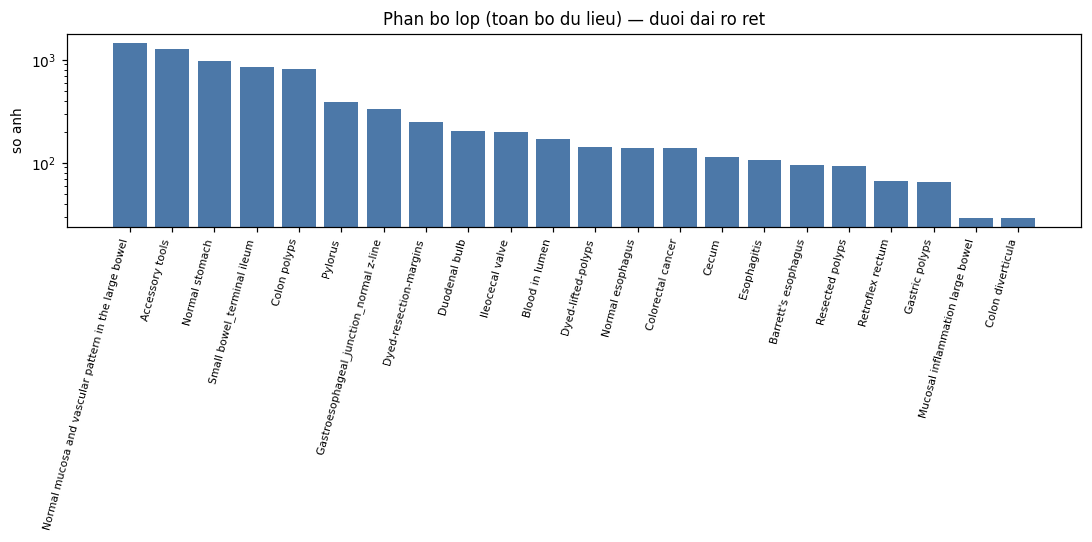

Ty le mat can bang (lop lon nhat / nho nhat): 50.6x


In [7]:
cnt_full = np.bincount(labels, minlength=NUM_CLASSES)
order = np.argsort(-cnt_full)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(NUM_CLASSES), cnt_full[order], color="#4C78A8")
ax.set_xticks(range(NUM_CLASSES))
ax.set_xticklabels([CLASSES[i] for i in order], rotation=75, ha="right", fontsize=7)
ax.set_ylabel("so anh"); ax.set_title("Phan bo lop (toan bo du lieu) — duoi dai ro ret")
ax.set_yscale("log")
plt.tight_layout(); plt.savefig(OUTPUT_DIR / "eda_class_distribution.png", dpi=130); plt.show()

print(f"Ty le mat can bang (lop lon nhat / nho nhat): {cnt_full.max() / cnt_full.min():.1f}x")

---
## 7. Dataset, phép biến đổi ảnh và bộ nạp dữ liệu

Augment giữ nguyên triết lý của bản GPU (lật ngang hợp lệ, **không** lật dọc, không augment mạnh).
Điểm khác duy nhất: `pin_memory=False` — pin memory chỉ có ích khi copy Host→GPU.

In [8]:
IMAGENET_MEAN, IMAGENET_STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]


def build_transforms(sz):
    train = transforms.Compose([
        transforms.Resize((sz, sz)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])
    ev = transforms.Compose([
        transforms.Resize((sz, sz)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])
    return train, ev


train_tf, eval_tf = build_transforms(IMG_SIZE)


class GastroDataset(Dataset):
    def __init__(self, indices, transform):
        self.items = [samples[i] for i in indices]
        self.transform = transform

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        path, y = self.items[i]
        return self.transform(Image.open(path).convert("RGB")), y


def make_loaders(batch=None):
    b = batch or BATCH_SIZE
    common = dict(batch_size=b, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                  worker_init_fn=seed_worker)
    tr = DataLoader(GastroDataset(train_idx, train_tf), shuffle=True, generator=DATA_GEN, **common)
    va = DataLoader(GastroDataset(val_idx, eval_tf), shuffle=False, **common)
    te = DataLoader(GastroDataset(test_idx, eval_tf), shuffle=False, **common)
    return tr, va, te


print("so anh:", len(train_idx), len(val_idx), len(test_idx), "| IMG_SIZE =", IMG_SIZE)

so anh: 4758 1586 1586 | IMG_SIZE = 224


---
## 8. Bộ đánh giá dùng chung

Giống bản GPU: `evaluate()` trả về **logits** để bootstrap CI / ensemble / TTA đều tính lại được
mà **không tốn thêm epoch**. Khác duy nhất: không có `autocast` — fp32 thuần trên CPU.

In [9]:
ALL_LABELS = list(range(NUM_CLASSES))


def macro_f1(y_true, y_pred):
    return f1_score(y_true, y_pred, labels=ALL_LABELS, average="macro", zero_division=0)


def softmax_np(z):
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)


@torch.no_grad()
def evaluate(model, loader, tta=False):
    '''Tra ve macro-F1, micro-F1, nhan that, nhan doan VA logits (float32). 100% CPU, fp32.'''
    model.eval()
    ys, ls = [], []
    for x, y in loader:
        out = model(x).float()
        if tta:                                   # TTA = trung binh voi anh lat ngang
            out = (out + model(torch.flip(x, dims=[3])).float()) / 2
        ls.append(out.numpy()); ys.append(y.numpy())
    logits = np.concatenate(ls).astype(np.float32)
    y_true = np.concatenate(ys)
    y_pred = logits.argmax(1)
    return dict(macro_f1=macro_f1(y_true, y_pred),
                micro_f1=f1_score(y_true, y_pred, labels=ALL_LABELS, average="micro", zero_division=0),
                y_true=y_true, y_pred=y_pred, logits=logits)


def report_per_class(res, title=""):
    print(f"--- F1 tung lop {title} ---")
    print(classification_report(res["y_true"], res["y_pred"], labels=ALL_LABELS,
                                target_names=CLASSES, zero_division=0, digits=3))


def plot_confusion(res, title="", fname=None):
    cm = confusion_matrix(res["y_true"], res["y_pred"], labels=ALL_LABELS)
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES, cbar=False)
    plt.xlabel("du doan"); plt.ylabel("that"); plt.title(f"Ma tran nham lan {title}")
    plt.xticks(rotation=75, ha="right", fontsize=6); plt.yticks(fontsize=6)
    plt.tight_layout()
    if fname:
        plt.savefig(OUTPUT_DIR / fname, dpi=130)
    plt.show()


def bootstrap_ci(y_true, y_pred, n_boot=1000, alpha=0.05, seed=0, verbose=True):
    '''Khoang tin cay 95% cho macro-F1 bang lay lai mau co hoan lai. 0 epoch.'''
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    rng = np.random.default_rng(seed)
    n = len(y_true)
    stats = []
    for _ in range(n_boot):
        i = rng.integers(0, n, n)
        present = np.unique(y_true[i])
        stats.append(f1_score(y_true[i], y_pred[i], labels=present, average="macro", zero_division=0))
    lo, hi = np.percentile(stats, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    point = macro_f1(y_true, y_pred)
    if verbose:
        print(f"macro-F1 = {point:.4f}   CI 95% [{lo:.4f}, {hi:.4f}]")
    return dict(point=float(point), lo=float(lo), hi=float(hi))


def ensemble_logits(list_of_logits, weights=None):
    '''Trung binh XAC SUAT (softmax) — nhu ban GPU.'''
    probs = [softmax_np(l) for l in list_of_logits]
    w = np.ones(len(probs)) if weights is None else np.asarray(weights, dtype=float)
    w = w / w.sum()
    return sum(wi * p for wi, p in zip(w, probs))


print("bo danh gia san sang | so lop =", NUM_CLASSES)

bo danh gia san sang | so lop = 22


---
## 9. Vòng huấn luyện — fp32 thuần trên CPU

Giữ nguyên `Tracker` với 3 quy tắc chọn checkpoint (`best` / `smooth` / `top3`) của bản GPU.
Bỏ hoàn toàn `autocast` + `GradScaler`: trên CPU chúng không tăng tốc mà chỉ thêm một nguồn sai khác.

In [10]:
class Tracker:
    '''Ghi lich su val + giu cac trang thai cho 3 quy tac chon checkpoint (nhu ban GPU).'''

    def __init__(self, keep_top_k=KEEP_TOP_K, smooth_win=SMOOTH_WIN):
        self.keep_top_k, self.smooth_win = keep_top_k, smooth_win
        self.history, self.top = [], []
        self.smooth = (-1.0, -1, None)

    def update(self, model, vf1, ep):
        self.history.append(float(vf1))
        state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        self.top.append((float(vf1), ep, state))
        self.top.sort(key=lambda t: -t[0])
        del self.top[self.keep_top_k:]
        sm = float(np.mean(self.history[-self.smooth_win:]))
        if sm > self.smooth[0]:
            self.smooth = (sm, ep, state)

    def finalize(self, model):
        model.load_state_dict(self.top[0][2])
        return dict(best_val=self.top[0][0], best_epoch=self.top[0][1],
                    history=self.history, top=self.top, smooth=self.smooth)


def train_one(model, tr, va, epochs=None, lr=1e-4, criterion=None, verbose=True):
    '''Fine-tune don gian (AdamW, fp32, CPU). Cung cong thuc voi ban GPU, bo AMP/GradScaler.'''
    epochs = epochs or EPOCHS
    crit = criterion if criterion is not None else nn.CrossEntropyLoss()
    params = [p for p in model.parameters() if p.requires_grad]
    opt = torch.optim.AdamW(params, lr=lr, weight_decay=1e-4)
    tk, dt = Tracker(), float("nan")
    for ep in range(epochs):
        model.train()
        t0 = time.time()
        for x, y in tr:
            opt.zero_grad(set_to_none=True)
            loss = crit(model(x), y)
            loss.backward()
            opt.step()
        dt = time.time() - t0
        vf1 = evaluate(model, va)["macro_f1"]
        tk.update(model, vf1, ep)
        if verbose:
            print(f"  ep {ep + 1:02d}/{epochs}  val_macroF1={vf1:.4f}  "
                  f"(best={tk.top[0][0]:.4f})  {dt:.0f}s/epoch")
    out = tk.finalize(model)
    out["sec_per_epoch"] = dt
    return out


print("ham huan luyen san sang (fp32, CPU)")

ham huan luyen san sang (fp32, CPU)


---
## 10. Mô hình — chọn theo tiêu chuẩn CPU

| Cờ | Mô hình | Vì sao |
| --- | --- | --- |
| mặc định | **MobileNetV3-Large** | thiết kế cho suy luận CPU (depthwise conv), ~5,5M tham số |
| `RUN_DENSENET = True` | DenseNet-121 | baseline tham chiếu của bài báo — chạy được nhưng chậm hơn ~3–4× trên CPU |

`check_forward()` kiểm shape **và** kiểm mọi tham số + buffer đều nằm trên CPU trước khi tốn
một epoch nào.

In [11]:
def build_mobilenet_v3(nc):
    m = tv.models.mobilenet_v3_large(weights=tv.models.MobileNet_V3_Large_Weights.IMAGENET1K_V2)
    m.classifier[3] = nn.Linear(m.classifier[3].in_features, nc)
    return m.to(DEVICE)


def build_densenet121(nc):
    m = tv.models.densenet121(weights=tv.models.DenseNet121_Weights.IMAGENET1K_V1)
    m.classifier = nn.Linear(m.classifier.in_features, nc)
    return m.to(DEVICE)


def check_forward(model, name=""):
    '''Kiem shape + kiem 100% tham so/buffer nam tren CPU truoc khi ton epoch nao.'''
    bad = [n for n, p in model.named_parameters() if p.device.type != "cpu"]
    bad += [n for n, b in model.named_buffers() if b.device.type != "cpu"]
    assert not bad, f"{name}: cac tensor sau KHONG nam tren CPU: {bad[:5]}"
    model.eval()
    with torch.no_grad():
        out = model(torch.zeros(2, 3, IMG_SIZE, IMG_SIZE))
    assert out.shape == (2, NUM_CLASSES), \
        f"{name}: dau ra {tuple(out.shape)} != (2, {NUM_CLASSES})"
    n_par = sum(p.numel() for p in model.parameters()) / 1e6
    print(f"  {name:16s} OK | {n_par:5.1f}M tham so | 100% CPU | dau vao {IMG_SIZE}x{IMG_SIZE}")
    return n_par


BUILDERS = {"mobilenet_v3": build_mobilenet_v3, "densenet121": build_densenet121}
PARAM_COUNTS = {}
for _k, _f in BUILDERS.items():
    _m = _f(NUM_CLASSES)
    PARAM_COUNTS[_k] = check_forward(_m, _k)
    del _m

  mobilenet_v3     OK |   4.2M tham so | 100% CPU | dau vao 224x224


  densenet121      OK |   7.0M tham so | 100% CPU | dau vao 224x224


---
## 11. Bộ chạy đa seed — tự khôi phục từ `.npz`

Giống bản GPU: mỗi seed huấn luyện **một lần**, rút ra 3 quy tắc × 2 chế độ TTA = 6 điểm số,
lưu logits ra đĩa (`checkpoints_cpu/`) để mọi phân tích sau đều 0 epoch. Nếu file `.npz` của
một seed đã tồn tại thì **không train lại**; đặt `FORCE_RERUN = True` nếu muốn train lại.

In [12]:
SELECTION_RULE = "best"
FORCE_RERUN    = False
RESULTS_STORE  = {}


def _npz(tag, seed):
    return CKPT_DIR / f"{tag}_seed{seed}.npz"


def run_seeds(build_fn, tag, seeds=None, train_fn=train_one, resume=True, **train_kw):
    seeds = SEEDS if seeds is None else seeds
    per_seed = []

    for s in seeds:
        path = _npz(tag, s)
        if resume and path.exists() and not FORCE_RERUN:
            d = np.load(path, allow_pickle=True)
            sc = json.loads(str(d["scores_json"]))
            print(f"[{tag} seed {s}] doc lai tu {path.name} (bo qua huan luyen)")
        else:
            set_seed(s)
            tr, va, te = make_loaders()
            model = build_fn(NUM_CLASSES)
            check_forward(model, tag)
            print(f"[{tag} seed {s}] bat dau huan luyen ({EPOCHS} epoch, batch {BATCH_SIZE}, CPU)")
            t0 = time.time()
            r = train_fn(model, tr, va, **train_kw)
            train_sec = time.time() - t0

            cand = list(r["top"])
            smooth_state = r["smooth"][2]
            smooth_i = next((i for i, (_, _, st) in enumerate(cand) if st is smooth_state), None)
            if smooth_i is None:
                cand.append((r["smooth"][0], r["smooth"][1], smooth_state))
                smooth_i = len(cand) - 1

            L, y_true = {}, None
            for i, (_, _, st) in enumerate(cand):
                model.load_state_dict(st)
                for tta in (False, True):
                    e = evaluate(model, te, tta=tta)
                    L[(i, tta)] = e["logits"]
                    y_true = e["y_true"]

            model.load_state_dict(cand[0][2])
            ev = evaluate(model, va)
            n_top = min(KEEP_TOP_K, len(r["top"]))

            sc, store = {}, {}
            for tta in (False, True):
                sfx = "_tta" if tta else ""
                ens = ensemble_logits([L[(i, tta)] for i in range(n_top)])
                store[f"logits_best{sfx}"] = L[(0, tta)]
                store[f"logits_smooth{sfx}"] = L[(smooth_i, tta)]
                store[f"probs_top{n_top}{sfx}"] = ens
                sc[f"best{sfx}"]   = macro_f1(y_true, L[(0, tta)].argmax(1))
                sc[f"smooth{sfx}"] = macro_f1(y_true, L[(smooth_i, tta)].argmax(1))
                sc[f"top3{sfx}"]   = macro_f1(y_true, ens.argmax(1))

            sc["best_val"] = r["best_val"]
            sc["train_sec"] = train_sec
            sc["sec_per_epoch"] = r.get("sec_per_epoch", float("nan"))

            np.savez_compressed(
                path, y_true=y_true, val_y=ev["y_true"], val_logits=ev["logits"],
                history=np.array(r["history"], dtype=np.float32),
                scores_json=json.dumps(sc), **store)
            torch.save(cand[0][2], CKPT_DIR / f"{tag}_seed{s}.pt")
            print(f"[{tag} seed {s}] xong sau {train_sec / 60:.1f} phut -> {path.name}")

        per_seed.append(sc)
        print("   " + "  ".join(f"{k}={sc[k]:.4f}" for k in
                                ("best", "best_tta", "smooth", "smooth_tta", "top3", "top3_tta")))

    rules = ["best", "best_tta", "smooth", "smooth_tta", "top3", "top3_tta"]
    agg = {r: (float(np.mean([d[r] for d in per_seed])), float(np.std([d[r] for d in per_seed])))
           for r in rules}
    RESULTS_STORE[tag] = dict(tag=tag, seeds=list(seeds), per_seed=per_seed, agg=agg)
    m, sd = agg[SELECTION_RULE]
    print(f"\n>>> {tag}  TEST macro-F1 (quy tac '{SELECTION_RULE}') = {m:.4f} +/- {sd:.4f}")
    if IS_LITE:
        print("    (che do cpu-lite: con so nay chi de chung minh code chay, khong co y nghia)")
    return RESULTS_STORE[tag]


def load_run(tag, seed):
    d = np.load(_npz(tag, seed), allow_pickle=True)
    out = {k: d[k] for k in d.files if k != "scores_json"}
    out["scores"] = json.loads(str(d["scores_json"]))
    return out


print("run_seeds san sang | thu muc luu:", CKPT_DIR)

run_seeds san sang | thu muc luu: C:\Users\QuangLT1\Desktop\MSE\07. Deep Learning\Final project\deep-learning-final\checkpoints_cpu


---
## 12. Huấn luyện trên CPU

`M0_mobilenetv3_cpu` là cấu hình mặc định. DenseNet-121 (baseline của bài báo) bật bằng
`RUN_DENSENET = True` — chỉ nên bật ở `cpu-lite` hoặc khi bạn thật sự có nhiều giờ CPU.

In [13]:
res_m0 = run_seeds(build_mobilenet_v3, tag="M0_mobilenetv3_cpu")

[M0_mobilenetv3_cpu seed 0] doc lai tu M0_mobilenetv3_cpu_seed0.npz (bo qua huan luyen)
   best=0.6191  best_tta=0.6434  smooth=0.6191  smooth_tta=0.6434  top3=0.6649  top3_tta=0.6737

>>> M0_mobilenetv3_cpu  TEST macro-F1 (quy tac 'best') = 0.6191 +/- 0.0000


In [14]:
RUN_DENSENET = True    # True = chay them DenseNet-121 (baseline bai bao) — cham hon ~3-4x tren CPU

if RUN_DENSENET:
    res_b0 = run_seeds(build_densenet121, tag="B0_densenet121_cpu")
else:
    res_b0 = None
    print("bo qua DenseNet-121 (dat RUN_DENSENET = True de chay)")

  B0_densenet121_cpu OK |   7.0M tham so | 100% CPU | dau vao 224x224
[B0_densenet121_cpu seed 0] bat dau huan luyen (15 epoch, batch 16, CPU)


  ep 01/15  val_macroF1=0.4444  (best=0.4444)  831s/epoch


  ep 02/15  val_macroF1=0.5406  (best=0.5406)  806s/epoch


  ep 03/15  val_macroF1=0.5891  (best=0.5891)  799s/epoch


  ep 04/15  val_macroF1=0.6324  (best=0.6324)  804s/epoch


...

  ep 12/15  val_macroF1=0.6501  (best=0.6806)  804s/epoch


  ep 13/15  val_macroF1=0.6387  (best=0.6806)  849s/epoch


  ep 14/15  val_macroF1=0.6578  (best=0.6806)  824s/epoch


  ep 15/15  val_macroF1=0.6552  (best=0.6806)  804s/epoch


[B0_densenet121_cpu seed 0] xong sau 224.9 phut -> B0_densenet121_cpu_seed0.npz
   best=0.6844  best_tta=0.6764  smooth=0.6665  smooth_tta=0.6689  top3=0.6969  top3_tta=0.6883

>>> B0_densenet121_cpu  TEST macro-F1 (quy tac 'best') = 0.6844 +/- 0.0000


---
## 13. Kết quả — 6 quy tắc đọc từ cùng một lần chạy

Bảng dưới không tốn thêm epoch nào: cả 6 cột (3 quy tắc chọn checkpoint × 2 chế độ TTA)
đều tính lại từ logits đã lưu.

In [15]:
rows = []
for tag, r in RESULTS_STORE.items():
    for rule, (m, sd) in r["agg"].items():
        rows.append(dict(mo_hinh=tag, quy_tac=rule, trung_binh=round(m, 4), do_lech=round(sd, 4)))

tab = pd.DataFrame(rows).pivot(index="mo_hinh", columns="quy_tac", values="trung_binh")
tab = tab[["best", "smooth", "top3", "best_tta", "smooth_tta", "top3_tta"]]
print("macro-F1 test theo tung quy tac chon checkpoint (trung binh tren cac seed)\n")
print(tab.to_string())
if IS_LITE:
    print("\n!! cpu-lite: bang nay chi minh hoa co che, khong dung de ket luan.")

macro-F1 test theo tung quy tac chon checkpoint (trung binh tren cac seed)

quy_tac               best  smooth    top3  best_tta  smooth_tta  top3_tta
mo_hinh                                                                   
B0_densenet121_cpu  0.6844  0.6665  0.6969    0.6764      0.6689    0.6883
M0_mobilenetv3_cpu  0.6191  0.6191  0.6649    0.6434      0.6434    0.6737


=== M0_mobilenetv3_cpu (quy tac 'best', seed dau tien) ===


macro-F1 = 0.6191   CI 95% [0.5737, 0.6571]
--- F1 tung lop M0_mobilenetv3_cpu ---
                                                       precision    recall  f1-score   support

                                      Accessory tools      0.912     0.945     0.928       253
                                  Barrett's esophagus      0.636     0.368     0.467        19
                                       Blood in lumen      0.644     0.853     0.734        34
                                                Cecum      0.412     0.304     0.350        23
                                    Colon diverticula      1.000     0.167     0.286         6
                                         Colon polyps      0.816     0.732     0.772       164
                                    Colorectal cancer      0.480     0.429     0.453        28
                                        Duodenal bulb      0.606     0.488     0.541        41
                                   Dyed-lifted-polyps      0.

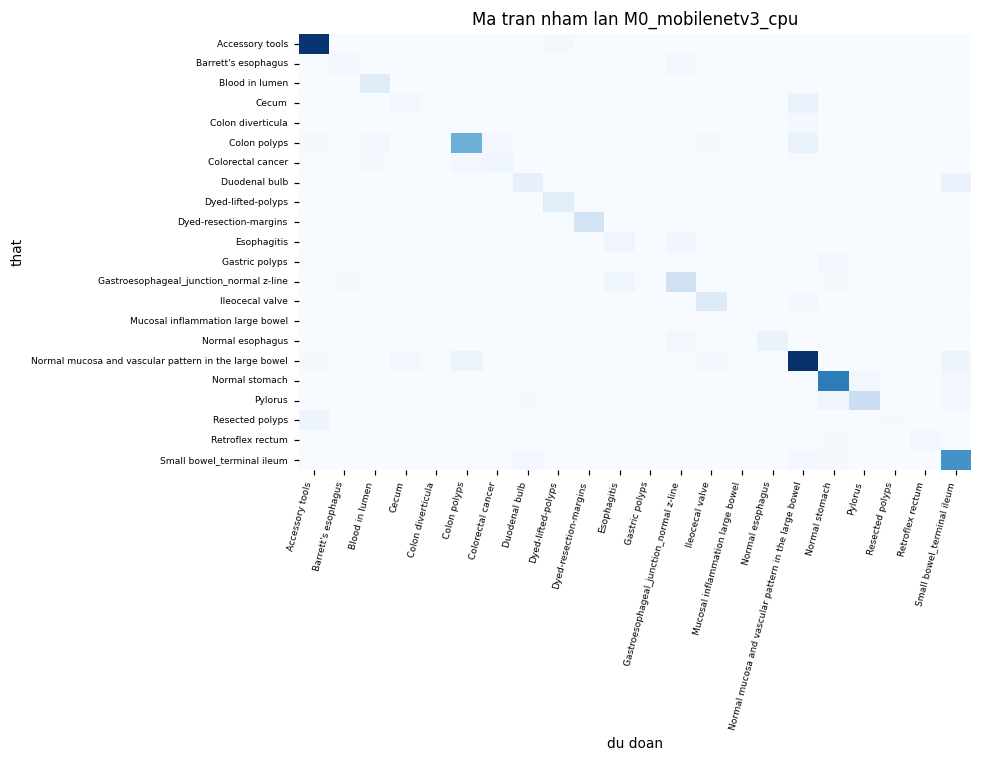

In [16]:
# Bootstrap CI + F1 tung lop + ma tran nham lan cho mo hinh mac dinh (0 epoch, doc tu logits da luu)
d0 = load_run("M0_mobilenetv3_cpu", SEEDS[0])
y_true = d0["y_true"]
y_pred = d0["logits_best"].argmax(1)

print("=== M0_mobilenetv3_cpu (quy tac 'best', seed dau tien) ===")
ci = bootstrap_ci(y_true, y_pred)

res_view = dict(y_true=y_true, y_pred=y_pred)
report_per_class(res_view, "M0_mobilenetv3_cpu")
plot_confusion(res_view, "M0_mobilenetv3_cpu", fname="confusion_m0_cpu.png")

---
## 14. Đo độ trễ suy luận trên CPU

Đo ms/ảnh ở batch = 1 (kịch bản triển khai thực tế trên máy không GPU) — fp32, số thread như
đã in ở ô đầu. Đây là con số dùng được cho phần "triển khai" của báo cáo khi đích đến là CPU.

In [17]:
@torch.no_grad()
def cpu_latency_ms(model, iters=None, warmup=5):
    iters = iters or CFG["latency_iters"]
    model.eval()
    x = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)
    for _ in range(warmup):
        model(x)
    t0 = time.perf_counter()
    for _ in range(iters):
        model(x)
    return (time.perf_counter() - t0) / iters * 1000


# Do ca hai kien truc ke ca khi khong fine-tune DenseNet: do tre chi can forward,
# khong can trong so da huan luyen.
lat_rows = []
for name, build in BUILDERS.items():
    m = build(NUM_CLASSES)
    ms = cpu_latency_ms(m)
    size_mb = sum(p.numel() * p.element_size() for p in m.parameters()) / 1e6
    lat_rows.append(dict(mo_hinh=name, ms_moi_anh=round(ms, 1),
                         tham_so_M=round(PARAM_COUNTS[name], 1), kich_thuoc_MB=round(size_mb, 1)))
    del m

print(f"Do tre suy luan CPU (batch=1, fp32, {torch.get_num_threads()} threads)\n")
print(pd.DataFrame(lat_rows).to_string(index=False))

Do tre suy luan CPU (batch=1, fp32, 12 threads)

     mo_hinh  ms_moi_anh  tham_so_M  kich_thuoc_MB
mobilenet_v3        21.7        4.2           16.9
 densenet121        72.1        7.0           27.9


---
## 15. Kết luận & cách dùng đúng notebook này

* **Toàn bộ thuật toán đã chạy 100% trên CPU**: CUDA bị ẩn từ trước khi import torch,
  mọi lời gọi `.cuda()` bị chặn, `check_forward` xác nhận từng tham số/buffer nằm trên CPU.
* Kết quả ở hồ sơ `cpu-lite` chỉ để **kiểm thử pipeline** — muốn số CPU thật, đổi
  `PROFILE = "cpu-full"` và chấp nhận thời gian chạy nhiều giờ.
* Con số đưa vào báo cáo chính vẫn lấy từ bản GPU (`gastrovision_classification.ipynb`);
  bản CPU đóng góp: (1) bằng chứng pipeline tất định và chạy được không cần GPU,
  (2) số đo **độ trễ suy luận CPU** cho phần triển khai.